# Bayesian Structural Causal Models: model specification
## Update & load packages

In [123]:
# data manipulation
using CSV, DataFrames, Query
using LazyArrays

# stats
using Distributions
using HypothesisTests

# modelling
using NNlib: softmax  # for classification tasks
using Turing
using Dagitty
using StatisticalRethinking, StructuralCausalModels

# plotting & diagnostics
using MCMCChains, StatsPlots, StatisticalRethinkingPlots

# include modules
include("./TuringModels.jl")

default(labels=false)
print("Running on ", Threads.nthreads(), " threads.")


Running on 4 threads.

![DAG](../Apodemus-vacc-DAGs/DAG.jpg)

In [152]:
dag = Dagitty.DAG(
:D => :E,
:D => :F,
:D => :M,
:D => :P,
:D => :R,
:F => :E,
:F => :M,
:M => :E,
:P => :E,
# :P => :F,
# :P => :M,
:P => :R,
:R => :E,
:R => :F,
:R => :M,
:S => :E,
:S => :F,
:S => :M,
:S => :P,
:S => :R,
:T => :E,
:T => :F,
:T => :M,
:T => :R,
:V => :E,
:V => :T,
:W => :E,
:W => :F,
:W => :M,
:W => :P,
:W => :R,
:W => :T,
)

DAG: {10, 30} directed simple Int64 graph with labels [:D, :E, :F, :M, :P, :R, :S, :T, :V, :W])


## Import data


In [153]:
rawdata = CSV.File("../data/joint_dataset_4analysis.csv";
    missingstring = "NA", pool = true) |>
    DataFrame

,Plate,Measure,Row,Col_5,Col_6,Col_7,Blank,ID,Block,Sex
,Int64,Int64,String1,Float64,Float64,Float64,Float64,Int64?,Int64?,String1?
1,18,1,G,2.59,2.005,1.397,0.069,1,1,M
2,9,1,D,2.498,2.189,1.762,0.079,2,1,M
3,11,1,G,2.981,2.674,2.439,0.069,2,1,M
4,27,1,G,0.888,0.537,0.355,0.107,2,1,M
5,36,1,E,2.042,1.613,1.112,0.087,2,1,M
6,4,1,C,1.362,0.912,0.538,0.061,3,1,M
7,5,1,F,0.049,0.06,0.054,0.075,3,1,M
8,16,1,H,0.063,0.071,0.066,0.084,3,1,M
9,5,1,H,1.04,0.638,0.36,0.066,4,1,M


In [154]:
dataclean =
    rawdata |>
    @dropna(:ID) |> # remove entries which lack lab ID or PIT tag IDs (cannot be imputed)
    @filter(_.vax_history != "DD") |> # keep only mice with a single vaccination or adjuvant
    @filter(_.days_since_1st_D_or_A > 7) |> # remove entries which were measured less than a week after vaccination
    # @dropna(:Diet) |> # remove entries which lack a Diet value  (should be imputed)
    # @dropna(:repro_bin) |> # remove entries which lack a repro value  (should be imputed)
    # @dropna(:Weight) |> # remove entries which lack a body mass measurement (should be imputed)
    # @dropna(:Fat_Scores_Sum) |> # drop missing fat scores  (should be imputed)
    # @filter(_.OD > 0) |> # remove individuals who didn't seroconvert
    DataFrame

,Plate,Measure,Row,Col_5,Col_6,Col_7,Blank,ID,Block,Sex
,Int64,Int64,String1,Float64,Float64,Float64,Float64,Int64,Int64?,String1?
1,18,1,G,2.59,2.005,1.397,0.069,1,1,M
2,27,1,G,0.888,0.537,0.355,0.107,2,1,M
3,36,1,E,2.042,1.613,1.112,0.087,2,1,M
4,4,1,C,1.362,0.912,0.538,0.061,3,1,M
5,5,1,F,0.049,0.06,0.054,0.075,3,1,M
6,16,1,H,0.063,0.071,0.066,0.084,3,1,M
7,5,1,H,1.04,0.638,0.36,0.066,4,1,M
8,27,1,F,0.066,0.086,0.066,0.102,4,1,M
9,1,1,F,1.593,1.051,0.662,0.067,5,1,M


In [155]:
# select only the last complete entry for each mouse
dataunique = dataclean |>
             @groupby(_.ID) |>
             @map({ID = key(_), days_since_1st_D_or_A = maximum(_.days_since_1st_D_or_A)}) |>
             DataFrame;

In [156]:
# join the rest of the columns
data = dataclean |>
       @join(dataunique, _.ID, _.ID, {_..., __...}) |>
       @unique(_.ID) |> # ensure no repeated measures
       DataFrame;
"Total number of individual wood mice: $(length(unique(data.ID)))"

"Total number of individual wood mice: 103"

In [157]:
describe(data)

,variable,mean,min,median,max,nmissing
,Symbol,Union…,Any,Union…,Any,Int64
1,Plate,9.8835,1,8.0,37,0
2,Measure,1.0,1,1.0,1,0
3,Row,,C,,H,0
4,Col_5,1.29674,0.047,1.426,3.01,0
5,Col_6,0.952524,0.046,0.937,2.82,0
6,Col_7,0.674019,0.048,0.576,2.734,0
7,Blank,0.0743689,0.052,0.066,0.438,0
8,ID,2.93113e8,1,57.0,841265814,0
9,Block,1.52239,1,2.0,2,36


## Encode features

In [158]:
# create log OD response variable
data.logOD = log.(10, 1 .+ data.OD)
# encoding
data.ismale = data.Sex .∈ Ref(["M"])
data.issupplemented = data.Diet .∈ Ref(["High"])
data.isreproductive = data.repro_bin .∈ Ref(["Reproductive"])
data.iswild = data.Env .∈ Ref(["Wild"])

# populate nodes
# data.E = standardize(ZScoreTransform, data.logOD)
## data.M = standardize(ZScoreTransform, data.Weight)
# data.M = data.Weight
# data.F = data.Fat_Scores_Sum
# data.T = data.days_since_1st_D_or_A
# data.W = @. ifelse(data.Env == "Wild", 1, 2)
# data.V = @. ifelse(data.isvax == 1, 1, 2)
# data.D = @. ifelse(data.Diet == "High", 1, 2)
# data.R = @. ifelse(data.repro_bin == "Reproductive", 1, 2)
# data.S = @. ifelse(data.Sex == "M", 1, 2)
# data.P = @. ifelse(data.isHp == 0, 1, 2)
# data.nP = data.nHp;

# binary version
data.E = standardize(ZScoreTransform, data.logOD)
# data.M = standardize(ZScoreTransform, data.Weight)
data.M = data.Weight
data.F = data.Fat_Scores_Sum
data.T = data.days_since_1st_D_or_A
data.W = data.Env .∈ Ref(["Wild"])
data.V = data.isvax
data.D = data.Diet .∈ Ref(["High"])
data.R = data.repro_bin .∈ Ref(["Reproductive"])
data.S = data.Sex .∈ Ref(["M"])
data.P = data.isHp
data.nP = data.nHp;

dag_df = data[!, [:E, :W, :V, :D, :R, :S, :M, :F, :T, :P, :nP]]
# Convert 1 / 0 to true / false
dag_df[!, :V] = convert(Vector{Bool}, dag_df[!, :V])
dag_df[!, :P] = convert(Vector{Bool}, dag_df[!, :P])

describe(dag_df)

,variable,mean,min,median,max,nmissing,eltype
,Symbol,Float64,Real,Float64,Real,Int64,Type
1,E,2.15577e-18,-1.49767,0.212741,1.88475,0,Float64
2,W,0.349515,0,0.0,1,0,Bool
3,V,0.825243,0,1.0,1,0,Bool
4,D,0.514563,0,1.0,1,0,Bool
5,R,0.252427,0,0.0,1,0,Bool
6,S,0.543689,0,1.0,1,0,Bool
7,M,21.2794,12.5,21.5,35.0,1,"Union{Missing, Float64}"
8,F,6.14198,4.0,6.0,9.5,22,"Union{Missing, Float64}"
9,T,23.2816,9,17.0,64,0,"Union{Missing, Int64}"


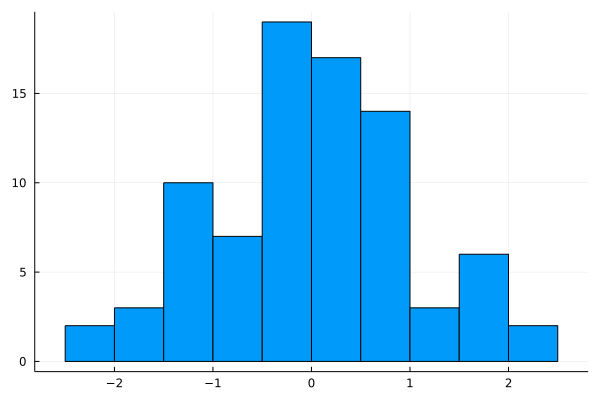

In [159]:
# Check that standardized logOD is a suitable transformation for immunised mice
seroconv = standardize(ZScoreTransform, data.E[data[!, :logOD] .> 0])

histogram(seroconv, bins=10)

In [160]:
ExactOneSampleKSTest(seroconv, Normal())

Exact one sample Kolmogorov-Smirnov test
----------------------------------------
Population details:
    parameter of interest:   Supremum of CDF differences
    value under h_0:         0.0
    point estimate:          0.0724615

Test summary:
    outcome with 95% confidence: fail to reject h_0
    two-sided p-value:           0.7484

Details:
    number of observations:   83


## Simulate variables that contain missing data using causal model

Two variables contain missing values, _F = f(T, W, D, S)_ and _M = f(T, W, D, R, S)_. We start by simulating each one to make sure our priors are reasonable.

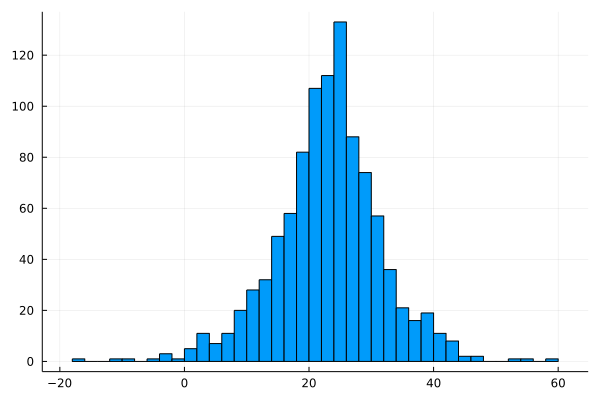

In [222]:
# Simulate M

n = 1000
complete_df = dropmissing(dag_df)

T = rand(Binomial(), n)
W = rand(Binomial(), n)
D = rand(Binomial(), n)
R = rand(Binomial(), n)
S = rand(Binomial(), n)
σ = rand(Normal(0, 3), n)
α = mean(complete_df.M)
σₘ = rand(truncated(Normal(0, 3), 0, Inf), n)

M = @. α + T*σ + W*σ + D*σ + R*σ + S*σ + σₘ



In [ ]:
histogram(M)

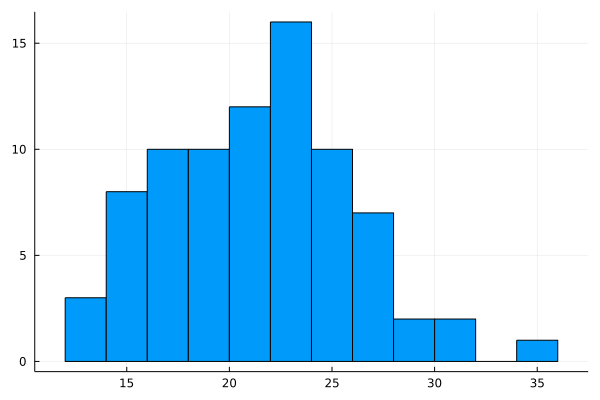

In [215]:
histogram(complete_df.M, bins=20)

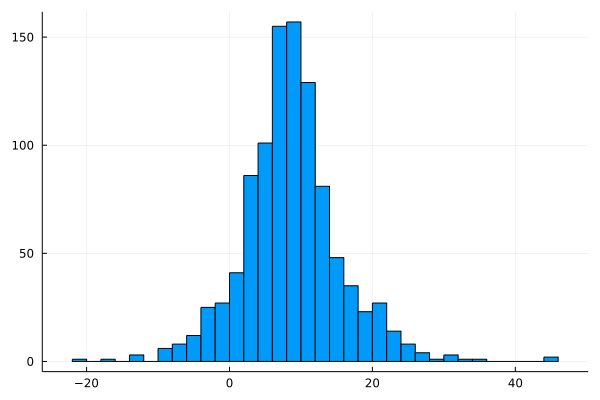

In [226]:
# Simulate F using the Dirichlet distribution

n = 1000
complete_df = dropmissing(dag_df)

T = rand(Binomial(), n)
W = rand(Binomial(), n)
D = rand(Binomial(), n)
S = rand(Binomial(), n)
σ = rand(Normal(0, 3), n)
α = mean(complete_df.F)
σf = rand(truncated(Normal(0, 3), 0, Inf), n)

F = @. α + T*σ + W*σ + D*σ + S*σ + σf

histogram(F)

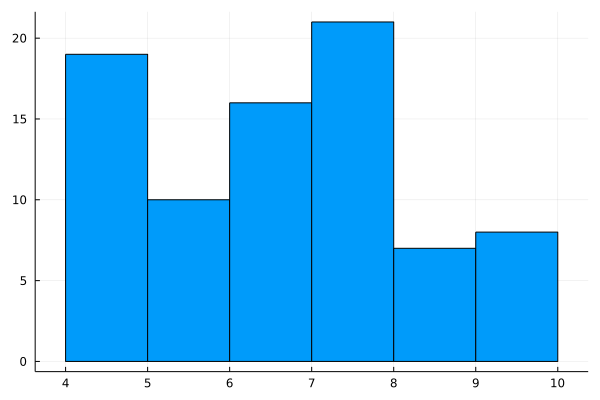

In [227]:
histogram(complete_df.F)